# Support Vector Machines (SVM)
### Author: Krzysztof Chmielewski

This notebook demonstrates Support Vector Machines implemented from scratch (linear and kernelized variants) and visualizes decision boundaries on synthetic datasets.

## Model Purpose and Applications

Support Vector Machines are supervised learning models for classification (and regression) that find a maximum-margin hyperplane separating classes. They rely on support vectors (training points closest to the decision boundary) and can use kernel functions to handle non-linearly separable data.

### Key Use Cases:
- Image and text classification
- Bioinformatics (e.g., gene expression classification)
- Small-to-medium sized datasets where feature engineering is feasible

### Core Concepts and Formulas
- Decision function: $f(x)=\mathbf{w}^T x + b$, prediction: $\operatorname{sign}(f(x))$.
- Hinge-loss SVM:

$$L(\mathbf{w}, b)=\frac{1}{2}\lVert\mathbf{w}\rVert^2 + C\sum_{i=1}^n\max(0,1 - y_i(\mathbf{w}^T x_i + b))$$

- Kernel trick: replace $x^T x'$ with kernel $K(x,x')=\langle\phi(x),\phi(x')\rangle$ (RBF, polynomial), enabling non-linear decision boundaries without explicit feature expansion.

### Strengths & Limitations
- Strengths: effective in high-dimensional spaces, robust margin-based generalization, flexible with kernels.
- Limitations: scales poorly to very large datasets, requires kernel/hyperparameter tuning, less straightforward probabilistic outputs.

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles

In [44]:
def plot_svm(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='bwr')

    # Hyperplane parameters
    w = model.W
    b = model.b

    # Create x values
    x1 = np.linspace(min(X[:,0])-1, max(X[:,0])+1, 100)
    
    # Decision boundary
    x2 = -(w[0]*x1 + b) / w[1]
    plt.plot(x1, x2, 'k-', label='Decision boundary')

    # Margins
    margin_up = -(w[0]*x1 + b - 1) / w[1]
    margin_down = -(w[0]*x1 + b + 1) / w[1]
    plt.plot(x1, margin_up, 'k--', label='Margin')
    plt.plot(x1, margin_down, 'k--')

    # Highlight support vectors (optional)
    y_ = np.where(y <= 0, -1, 1)
    support_vectors = X[np.abs(y_ * (X @ w + b) - 1) < 1e-3]
    plt.scatter(support_vectors[:,0], support_vectors[:,1], s=100, 
                facecolors='none', edgecolors='k', label='Support Vectors')

    plt.legend()
    plt.show()


In [42]:
class LinearSVM:
    def __init__(self, lr: float = 0.01, lambda_param: float = 0.01, n_iters: int = 1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.W = None
        self.b = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)

        self.W = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for i, x in enumerate(X):
                condition = y_[i] * (x @ self.W + self.b) >= 1
                if condition:
                    self.W -= self.lr * (2 * self.lambda_param * self.W)
                else:
                    self.W -= self.lr * (2 * self.lambda_param * self.W - y_[i] * x)
                    self.b += self.lr * y_[i]

    def predict(self, X):
        linear_output = X @ self.W + self.b
        return np.sign(linear_output)

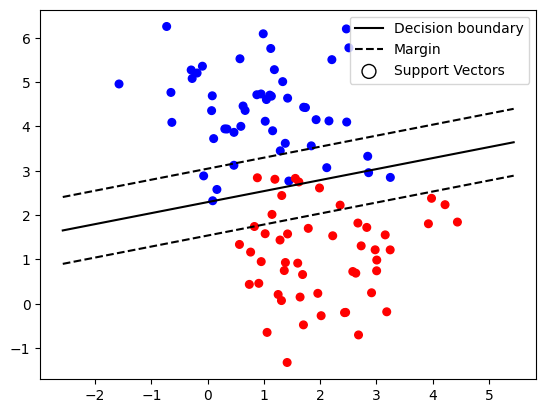

In [60]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0)
y = np.where(y == 0, -1, 1)

svm = LinearSVM()
svm.fit(X, y)
plot_svm(X, y, svm)

In [63]:
def linear_kernel(x, y):
    return np.dot(x, y)

def polynomial_kernel(x, y, degree=3, c=1):
    return (np.dot(x, y) + c)**degree

def rbf_kernel(x, y, gamma=1):
    return np.exp(-gamma * np.linalg.norm(x-y)**2)

class KernelSVM:
    def __init__(self, C: float = 1.0, kernel = rbf_kernel, lr: float = 0.01, n_iters: int = 1000):
        self.C = C
        self.kernel = kernel
        self.lr = lr
        self.n_iters = n_iters

    def fit(self, X, y, eps=1e-5):
        n = len(X)
        y = np.where(y <= 0, -1, 1)

        self.alpha = np.zeros(n)

        K = np.zeros((n,n))
        for i in range(n):
            for j in range(n):
                K[i,j] = self.kernel(X[i], X[j])

        for _ in range(self.n_iters):
            for i in range(n):
                margin = y[i] * np.sum(self.alpha * y * K[:,i])

                if margin < 1:
                    self.alpha[i] += self.lr * (1 - margin)
                else:
                    self.alpha[i] -= self.lr * (self.C * self.alpha[i])

        self.X = X
        self.y = y

        idx = np.where((self.alpha > eps) & (self.alpha < self.C))[0]
        if len(idx) == 0: self.b = 0
        else: 
            self.b = np.mean([
                y[i] - np.sum(self.alpha * y * K[:, i]) for i in idx
            ])

    def predict(self, X):
        y_pred = []
        for x in X:
            score = 0
            for i in range(len(self.alpha)):
                if self.alpha[i] > 0:
                    score += self.alpha[i] * self.y[i] * self.kernel(x, self.X[i])
            
            score += self.b
            y_pred.append(np.sign(score))
        return np.array(y_pred)